In [1]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import re
from spc import SPC3
from qua_tools_nv2.dataset import DatasetReader


In [ ]:
spad_root_dir = r'C:\Users\SPUD1\Documents\experiment_workspace\SPAD data'
spc3_dir = r'C:\Users\SPUD1\Documents\experiment_workspace\SPAD data\spc3'
qm_dir = r'C:\Users\SPUD1\Documents\experiment_workspace\qua-libs\Quantum-Control-Applications\Optically addressable spin qubits\NV2_array_SPAD'

#spad_processed_file = 'contacq_ODMR_ensemble__89_cw_odmr_165347_bgsub_avg_metadata.txt'
spad_processed_file = None
spad_file_header = 'contacq_ODMR_ensemble'
spad_background = 'background'
qm_file = r'C:\Users\SPUD1\Documents\experiment_workspace\qua-libs\Quantum-Control-Applications\Optically addressable spin qubits\NV2_array_SPAD\Data\2026-03-15\#89_cw_odmr_165347'

spad_processed_file = None if spad_processed_file is None else str(spad_processed_file).strip()
if isinstance(spad_processed_file, str) and spad_processed_file.upper() == 'NONE':
    spad_processed_file = None

use_processed_data = spad_processed_file is not None
processed_dir = Path(spad_root_dir) / 'processed'
if use_processed_data:
    processed_stem = Path(spad_processed_file).stem
    if processed_stem.endswith('_metadata'):
        processed_stem = processed_stem[:-9]
    processed_npz_path = processed_dir / f'{processed_stem}.npz'
    processed_meta_path = processed_dir / f'{processed_stem}_metadata.txt'
    print(f'Processed-data mode: ON -> {processed_npz_path.name}')
else:
    processed_stem = None
    processed_npz_path = None
    processed_meta_path = None
    print('Processed-data mode: OFF (will load raw SPC3 files)')

Processed-data mode: ON -> contacq_ODMR_ensemble__89_cw_odmr_165347_bgsub_avg.npz


In [26]:
# Toggle whether to use LO frequency (absolute MW freq) or just IF
USE_LO_FREQUENCY = False  # Set False to work in IF space

reader = DatasetReader(qm_dir)

ds_folder = reader.resolve_dataset(qm_file).folder
ds = reader.resolve_dataset(ds_folder)
data = reader.load(ds)

if_hz = np.asarray(data['IF_frequencies'], dtype=float)

cfg = data.get('config') or {}
if USE_LO_FREQUENCY:
    lo_hz = float(cfg['elements']['NV']['mixInputs']['lo_frequency'])
    f_mw_hz = lo_hz + if_hz
else:
    lo_hz = None
    f_mw_hz = if_hz

n_avg = int(data.get('n_avg', 1))
# 'iteration' is 0-indexed:
# Falls back to n_avg when the field is absent
n_iteration = int(data.get('iteration', n_avg - 1)) + 1

print(f'Loaded: {ds.folder}')
print(f"n_avg        : {n_avg}  (requested)")
print(f"n_iteration  : {n_iteration}  (actually completed)")
if n_iteration != n_avg:
    print(f"  ↳ experiment was interrupted at {n_iteration / n_avg * 100:.1f}% of target")
print(f"len(if_hz)   : {len(if_hz)}")
print(f"if_hz range  : {if_hz.min()/1e6:.1f} – {if_hz.max()/1e6:.1f} MHz")
print(f"Expected total frames: {2 * n_iteration * len(if_hz)}") #sig,ref frames per iteration, per frequency point


Loaded: C:\Users\SPUD1\Documents\experiment_workspace\qua-libs\Quantum-Control-Applications\Optically addressable spin qubits\NV2_array_SPAD\Data\2026-03-15\#89_cw_odmr_165347
n_avg        : 100000  (requested)
n_iteration  : 100000  (actually completed)
len(if_hz)   : 60
if_hz range  : 65.0 – 94.5 MHz
Expected total frames: 12000000


In [27]:
if use_processed_data:
    if not processed_npz_path.exists():
        raise FileNotFoundError(f'Processed file not found: {processed_npz_path}')

    with np.load(processed_npz_path, allow_pickle=False) as proc:
        required = ['sig_avg_cps_bgsub', 'ref_avg_cps_bgsub']
        missing = [k for k in required if k not in proc.files]
        if missing:
            raise KeyError(f'Missing key(s) in {processed_npz_path.name}: {missing}')

        sig_avg_cps_bgsub = np.asarray(proc['sig_avg_cps_bgsub'], dtype=np.float64)
        ref_avg_cps_bgsub = np.asarray(proc['ref_avg_cps_bgsub'], dtype=np.float64)

        if 'f_vec' in proc.files:
            f_vec = np.asarray(proc['f_vec'], dtype=np.float64)
        else:
            f_vec = np.asarray(f_mw_hz, dtype=np.float64)

        if 'bg_avg_cps' in proc.files:
            bg_avg_cps = np.asarray(proc['bg_avg_cps'], dtype=np.float64)
        else:
            bg_avg_cps = np.zeros(sig_avg_cps_bgsub.shape[1:], dtype=np.float64)

        if 'integration_time_s' in proc.files:
            integration_time_s = float(np.asarray(proc['integration_time_s']).item())
        else:
            integration_time_s = 1.0

        if 'n_complete_reps' in proc.files:
            n_complete_reps = int(np.asarray(proc['n_complete_reps']).item())
        else:
            n_complete_reps = int(n_iteration)

        if 'num_iterations' in proc.files:
            n_iteration = int(np.asarray(proc['num_iterations']).item())

    f_mw_hz = np.asarray(f_vec, dtype=np.float64)
    F, n_rows, n_cols = sig_avg_cps_bgsub.shape
    ref_avg_cps = ref_avg_cps_bgsub + bg_avg_cps
    sig_avg_cps = sig_avg_cps_bgsub + bg_avg_cps
    ref_avg = ref_avg_cps * integration_time_s
    sig_avg = sig_avg_cps * integration_time_s
    spc3_files = []
    header = None
    header_bg = None
    spad_dir_path = Path(spc3_dir)

    print(f'Loaded processed arrays from {processed_npz_path.name}')
    print(f'  sig_avg_cps_bgsub shape: {sig_avg_cps_bgsub.shape}')
    print(f'  ref_avg_cps_bgsub shape: {ref_avg_cps_bgsub.shape}')
    print(f'  f_vec points           : {len(f_mw_hz)}')
    print('Skipping raw SPC3 discovery/loading cells.')
else:
    spad_dir_path = Path(spc3_dir)

    # -----------------------------------------------------------------
    # Discover all part-files matching <header>.spc3, <header>2.spc3, ...
    # Only digits (never other text) may follow the header — this prevents
    # "ODMR_test_new.spc3" being picked up when header is "ODMR_test".
    # -----------------------------------------------------------------
    def _spc3_sort_key(p):
        m = re.search(r'(\d+)\.spc3$', p.name, re.IGNORECASE)
        return int(m.group(1)) if m else 0

    _part_re = re.compile(
        r'^' + re.escape(spad_file_header) + r'\d*\.spc3$',
        re.IGNORECASE
    )

    spc3_files = sorted(
        (p for p in spad_dir_path.glob(f'{spad_file_header}*.spc3') if _part_re.match(p.name)),
        key=_spc3_sort_key
    )

    if not spc3_files:
        raise FileNotFoundError(
            f"No SPC3 files found matching '{spad_file_header}[<digits>].spc3' in\n  {spad_dir_path}"
        )

    print(f"Found {len(spc3_files)} SPC3 file(s):")
    for fp in spc3_files:
        print(f"  {fp.name}")

Loaded processed arrays from contacq_ODMR_ensemble__89_cw_odmr_165347_bgsub_avg.npz
  sig_avg_cps_bgsub shape: (60, 32, 32)
  ref_avg_cps_bgsub shape: (60, 32, 32)
  f_vec points           : 60
Skipping raw SPC3 discovery/loading cells.


In [28]:
if use_processed_data:
    print('Processed-data mode active: skipping first-file SPC3 header read.')
else:
    # extract metadata from first file
    frames, header = SPC3.ReadSPC3DataFile(spc3_files[0])

    # frames shape: (n_counters, n_frames, n_cols, n_rows)
    print("=== Header (first file) ===")
    #print(f"  camera_id    : {header.camera_id}")
    #print(f"  serial       : {header.SN}")
    #print(f"  firmware ver : {header.FW_VER}")
    print(f"  n_frames     : {header.N_frames}")
    print(f"  n_counters   : {header.N_counters}")
    print(f"  n_rows       : {header.N_rows}")
    print(f"  n_cols       : {header.N_cols}")
    print(f"  bits/pixel   : {header.bit_x_pix}")
    print(f"  n_pixels     : {header.N_pix}")
    print(f"  HW integ time: {header.HwIntTime * 1e6:.3f} µs")
    print(f"  summed frames: {header.SummedFrames}")
    print(f"  coarse gate C1: {header.CoarseGate_C1_ON}  ")
    integration_time_s = header.CoarseGate_C1_stopPos - header.CoarseGate_C1_startPos
    print(f"integration time = {integration_time_s * 1e9:.3f} ns")

    print(f"\n=== Frames (first file) ===")
    print(f"  shape : {frames.shape}  (n_counters, n_frames, n_cols, n_rows)")
    print(f"  dtype : {frames.dtype}")
    print(f"  min/max (counter 0): {frames[0].min()}, {frames[0].max()}")

Processed-data mode active: skipping first-file SPC3 header read.


In [29]:
#run if course gate mode settings not saved in spc3 file
if not use_processed_data and header is not None and not header.CoarseGate_C1_ON:
    integration_time_s = 4000e-9 


In [30]:
if use_processed_data:
    print('Processed-data mode active: skipping background SPC3 read.')
else:
    # extract metadata from background file
    frames_bg, header_bg = SPC3.ReadSPC3DataFile(str(spad_dir_path / f'{spad_background}.spc3'))

    # frames shape: (n_counters, n_frames, n_cols, n_rows)
    print("=== Header (background file) ===")
    #print(f"  camera_id    : {header.camera_id}")
    #print(f"  serial       : {header.SN}")
    #print(f"  firmware ver : {header.FW_VER}")
    print(f"  n_frames     : {header_bg.N_frames}")
    print(f"  n_counters   : {header_bg.N_counters}")
    print(f"  n_rows       : {header_bg.N_rows}")
    print(f"  n_cols       : {header_bg.N_cols}")
    print(f"  bits/pixel   : {header_bg.bit_x_pix}")
    print(f"  n_pixels     : {header_bg.N_pix}")
    print(f"  HW integ time: {header_bg.HwIntTime * 1e6:.3f} µs")
    print(f"  summed frames: {header_bg.SummedFrames}")
    print(f"  coarse gate C1: {header_bg.CoarseGate_C1_ON}  "
          f"({header_bg.CoarseGate_C1_startPos * 1e9:.0f} – {header_bg.CoarseGate_C1_stopPos * 1e9:.0f} ns)")

    print(f"\n=== Frames (background file) ===")
    print(f"  shape : {frames_bg.shape}  (n_counters, n_frames, n_cols, n_rows)")
    print(f"  dtype : {frames_bg.dtype}")
    print(f"  min/max (counter 0): {frames_bg[0].min()}, {frames_bg[0].max()}")

    frames_bg = frames_bg[0].astype(np.float64)  # (n_frames, n_cols, n_rows)
    bg_avg = frames_bg.mean(axis=0)  # (rows, cols)
    bg_avg_cps = bg_avg / (header_bg.HwIntTime * header_bg.SummedFrames)  # counts per second per pixel

    plt.imshow(bg_avg_cps, cmap='inferno')
    plt.colorbar(label='cps')
    plt.title('Background')
    plt.show()

Processed-data mode active: skipping background SPC3 read.


In [31]:
if use_processed_data:
    print('Processed-data mode active: skipping raw SPC3 frame aggregation.')
else:
    # load all data files
    F = len(f_mw_hz)
    frames_per_rep = 2 * F

    header = None
    sig_sum = None   # (F, rows, cols) float64
    ref_sum = None   # (F, rows, cols) float64
    n_complete_reps = 0
    n_rows = n_cols = None
    carry = None
    N_frames_raw = 0

    for fp in spc3_files:
        f_data, h = SPC3.ReadSPC3DataFile(str(fp))
        frames = f_data[0]          # (N, rows, cols) — native uint8 or uint16
        N_frames_raw += frames.shape[0]

        if header is None:
            header = h
            n_rows, n_cols = frames.shape[1], frames.shape[2]
            sig_sum = np.zeros((F, n_rows, n_cols), dtype=np.float64)
            ref_sum = np.zeros((F, n_rows, n_cols), dtype=np.float64)

        if carry is not None:
            frames = np.concatenate([carry, frames], axis=0)
            carry = None

        n_frames = frames.shape[0]
        n_complete_here = (n_frames // frames_per_rep) * frames_per_rep

        if n_complete_here > 0:
            batch = frames[:n_complete_here].astype(np.float64)
            rep_view = batch.reshape(-1, F, 2, n_rows, n_cols)
            sig_sum += rep_view[:, :, 0, :, :].sum(axis=0)
            ref_sum += rep_view[:, :, 1, :, :].sum(axis=0)
            n_complete_reps += n_complete_here // frames_per_rep

        if n_frames > n_complete_here:
            carry = frames[n_complete_here:]

        print(f"  {fp.name}: {n_complete_here} frames used  "
              f"(running total: {n_complete_reps} complete reps)")

    dropped = N_frames_raw - n_complete_reps * frames_per_rep
    print(f"\nTotal frames raw     : {N_frames_raw}")
    print(f"Complete repetitions : {n_complete_reps}  ({n_complete_reps / n_iteration * 100:.1f}% of {n_iteration} completed, {n_avg} requested)")
    if dropped:
        print(f"Dropped trailing     : {dropped} frame(s) (incomplete final repetition)")

    sig_avg = sig_sum / n_complete_reps   # (F, rows, cols) float64
    ref_avg = ref_sum / n_complete_reps   # (F, rows, cols) float64

    sig_avg_cps = sig_avg / (header.HwIntTime * header.SummedFrames)  # counts per second per pixel
    ref_avg_cps = ref_avg / (header.HwIntTime * header.SummedFrames)  # counts per second per pixel

    print(f"sig_avg shape    : {sig_avg.shape}  dtype: {sig_avg.dtype}")
    print(f"Mean counts/px   : sig={sig_avg.mean():.4f}  ref={ref_avg.mean():.4f}")

Processed-data mode active: skipping raw SPC3 frame aggregation.


In [32]:
if use_processed_data:
    print('Processed-data mode active: using loaded bg-subtracted arrays.')
else:
    sig_avg_cps = sig_avg / integration_time_s # counts per second per pixel
    ref_avg_cps = ref_avg / integration_time_s # counts per second per pixel

    #background-subtracted signal and reference
    sig_avg_cps_bgsub = sig_avg_cps - bg_avg_cps
    ref_avg_cps_bgsub = ref_avg_cps - bg_avg_cps

Processed-data mode active: using loaded bg-subtracted arrays.


In [33]:
if use_processed_data:
    print('Processed-data mode active: export cell skipped (arrays already loaded from processed file).')
else:
    # Save processed/averaged bg-subtracted arrays + metadata
    out_dir = Path(spad_root_dir) / 'processed'
    out_dir.mkdir(parents=True, exist_ok=True)

    dataset_tag = re.sub(r'[^A-Za-z0-9_.-]+', '_', Path(qm_file).name)
    base_name = f"{spad_file_header}_{dataset_tag}_bgsub_avg"
    array_path = out_dir / f"{base_name}.npz"
    meta_path = out_dir / f"{base_name}_metadata.txt"

    f_vec = np.asarray(f_mw_hz, dtype=float)
    num_iterations = int(n_iteration)

    def _to_builtin(value):
        if isinstance(value, np.generic):
            return value.item()
        if isinstance(value, np.ndarray):
            return value.tolist()
        if isinstance(value, Path):
            return str(value)
        if isinstance(value, dict):
            return {str(k): _to_builtin(v) for k, v in value.items()}
        if isinstance(value, (list, tuple, set)):
            return [_to_builtin(v) for v in value]
        try:
            json.dumps(value)
            return value
        except (TypeError, OverflowError):
            return str(value)

    def _obj_to_dict(obj):
        try:
            raw = vars(obj)
            if raw:
                return {k: _to_builtin(v) for k, v in raw.items()}
        except TypeError:
            pass

        out = {}
        for name in dir(obj):
            if name.startswith('_'):
                continue
            try:
                val = getattr(obj, name)
            except Exception:
                continue
            if callable(val):
                continue
            out[name] = _to_builtin(val)
        return out

    # Save data arrays in compressed form (all are shape (F, n_rows, n_cols) except f_vec)
    np.savez_compressed(
        array_path,
        sig_avg_cps_bgsub=sig_avg_cps_bgsub,
        ref_avg_cps_bgsub=ref_avg_cps_bgsub,
        f_vec=f_vec,
        num_iterations=num_iterations,
        f_if_hz=if_hz if 'if_hz' in globals() else None,
        n_complete_reps=n_complete_reps,
        integration_time_s=integration_time_s,
        bg_avg_cps=bg_avg_cps,
        bg_file=str(spad_dir_path / f'{spad_background}.spc3'),
    )

    metadata_export = {
        'export': {
            'array_file': str(array_path),
            'metadata_file': str(meta_path),
            'array_shapes': {
                'sig_avg_cps_bgsub': list(sig_avg_cps_bgsub.shape),
                'ref_avg_cps_bgsub': list(ref_avg_cps_bgsub.shape),
                'f_vec': list(np.shape(f_vec)),
                'bg_avg_cps': list(np.shape(bg_avg_cps)),
            },
        },
        'run_info': {
            'num_iterations': num_iterations,
            'n_complete_reps': int(n_complete_reps),
        },
        'independent_variable': {
            'name': 'f_vec',
            'values_hz': _to_builtin(f_vec),
            'source': 'f_mw_hz loaded from qm_file',
        },
        'spc3_metadata': {
            'measurement_header': _obj_to_dict(header),
            'background_header': _obj_to_dict(header_bg),
        },
        'qm_source': {
            'qm_file': str(qm_file),
        },
    }

    with open(meta_path, 'w', encoding='utf-8') as f:
        f.write('SPAD ODMR processed export metadata\n')
        f.write('=' * 36 + '\n\n')
        f.write(json.dumps(metadata_export, indent=2))

    print(f'Saved arrays   -> {array_path}')
    print(f'Saved metadata -> {meta_path}')
    print(f'sig_avg_cps_bgsub shape: {sig_avg_cps_bgsub.shape}')
    print(f'ref_avg_cps_bgsub shape: {ref_avg_cps_bgsub.shape}')
    print(f'f_vec shape: {f_vec.shape}')
    print(f'num_iterations: {num_iterations}')

Processed-data mode active: export cell skipped (arrays already loaded from processed file).


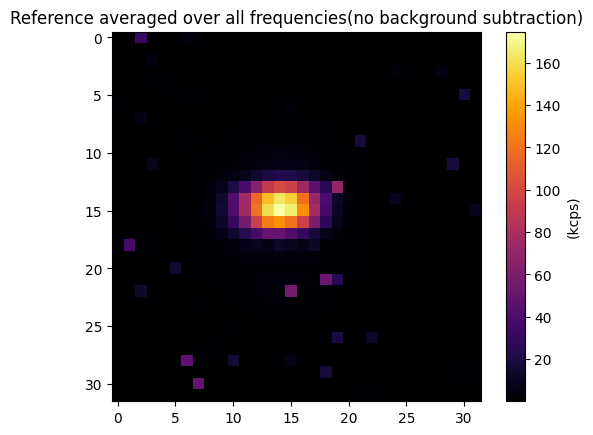

In [34]:
plt.imshow(1e-3*ref_avg_cps.mean(axis =0), cmap='inferno')
plt.colorbar(label='(kcps)')
plt.title('Reference averaged over all frequencies(no background subtraction)')
plt.show()


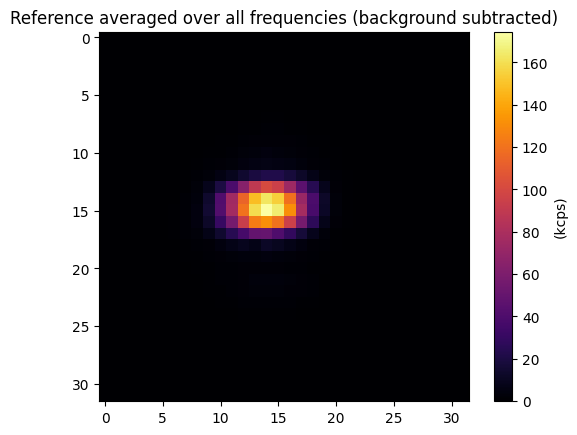

In [35]:
plt.imshow(1e-3*ref_avg_cps_bgsub.mean(axis=0), cmap='inferno')
plt.title('Reference averaged over all frequencies (background subtracted)')
plt.colorbar(label='(kcps)')
plt.show()

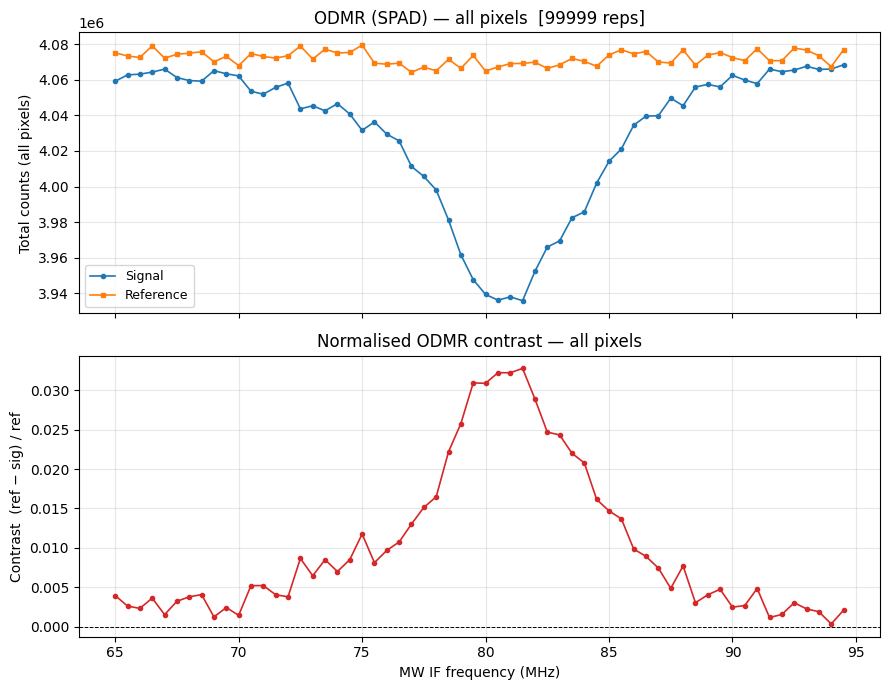

In [36]:
f_mhz = f_mw_hz / 1e6

# Sum all pixels at each frequency — identical to SPAD_ODMR_test
#sig_counts  = sig_avg.sum(axis=(-1, -2))   # (F,)
#ref_counts  = ref_avg.sum(axis=(-1, -2))   # (F,)

sig_counts  = sig_avg_cps_bgsub.sum(axis=(-1, -2))   # (F,)
ref_counts  = ref_avg_cps_bgsub.sum(axis=(-1, -2))   # (F,)

with np.errstate(divide='ignore', invalid='ignore'):
    contrast_all = np.where(ref_counts != 0, (ref_counts - sig_counts) / ref_counts, 0.0)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axes[0].plot(f_mhz, sig_counts, 'o-', ms=3, lw=1.2, label='Signal')
axes[0].plot(f_mhz, ref_counts, 's-', ms=3, lw=1.2, label='Reference')
axes[0].set_ylabel('Total counts (all pixels)')
axes[0].set_title(f'ODMR (SPAD) — all pixels  [{n_complete_reps} reps]')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(f_mhz, contrast_all, 'o-', ms=3, lw=1.2, color='C3')
axes[1].axhline(0, color='k', lw=0.7, ls='--')
axes[1].set_xlabel('MW IF frequency (MHz)')
axes[1].set_ylabel('Contrast  (ref − sig) / ref')
axes[1].set_title('Normalised ODMR contrast — all pixels')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Array centre (brightest pixel in ref_avg.mean): row=15, col=14


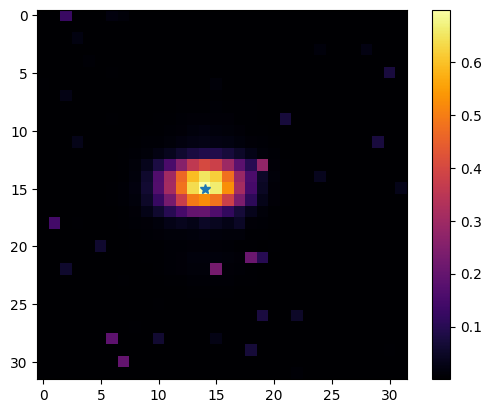

In [37]:
# Use the mean reference frame (averaged over all frequencies) to find the array centre.
# ref_avg has no ODMR dip, so every frequency contributes equally — more robust than
# using a single signal frame that may be suppressed near resonance.
ref_frame = ref_avg.mean(axis=0)  # (rows, cols) — mean reference over all frequencies
bright_rc = np.unravel_index(ref_frame.argmax(), ref_frame.shape)
print(f'Array centre (brightest pixel in ref_avg.mean): row={bright_rc[0]}, col={bright_rc[1]}')

plt.imshow(ref_frame, cmap='inferno')
plt.plot(bright_rc[1], bright_rc[0], '*', ms=7)
plt.colorbar()
plt.show()

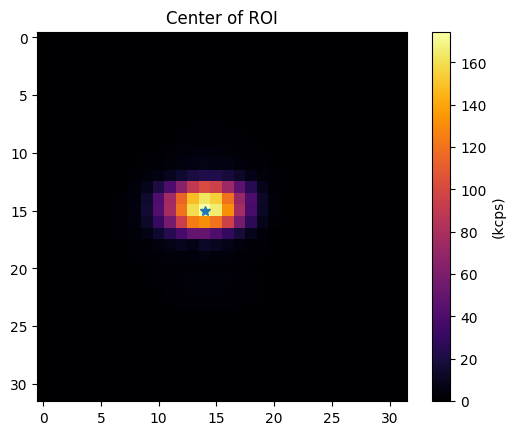

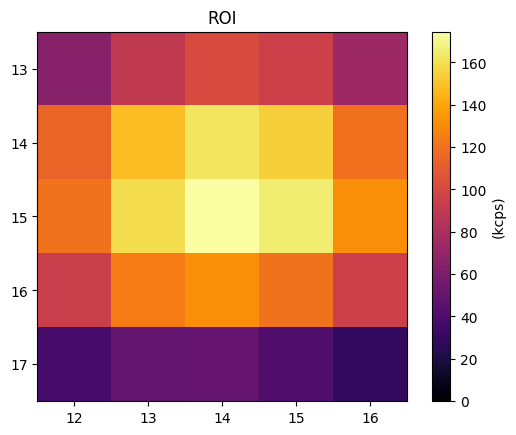

In [38]:
# option: manually set center of ROI 
bright_rc = (15,14)
n = 5 # size of ROI (n x n pixels)

#plot ref image with emitter centre marked
plt.imshow(1e-3*ref_avg_cps_bgsub.mean(axis=0), cmap='inferno')
plt.plot(bright_rc[1], bright_rc[0], '*', ms=7)
plt.colorbar(label='(kcps)')
plt.title('Center of ROI')
plt.show()

#plot zoom in around emitter array
plt.imshow(1e-3*ref_avg_cps_bgsub.mean(axis=0), cmap='inferno')
plt.colorbar(label='(kcps)')
plt.xlim(bright_rc[1]-int(n/2)-0.5, bright_rc[1]+int(n/2)+0.5)
plt.ylim(bright_rc[0]+int(n/2)+0.5, bright_rc[0]-int(n/2)-0.5)
plt.title('ROI')
plt.show()

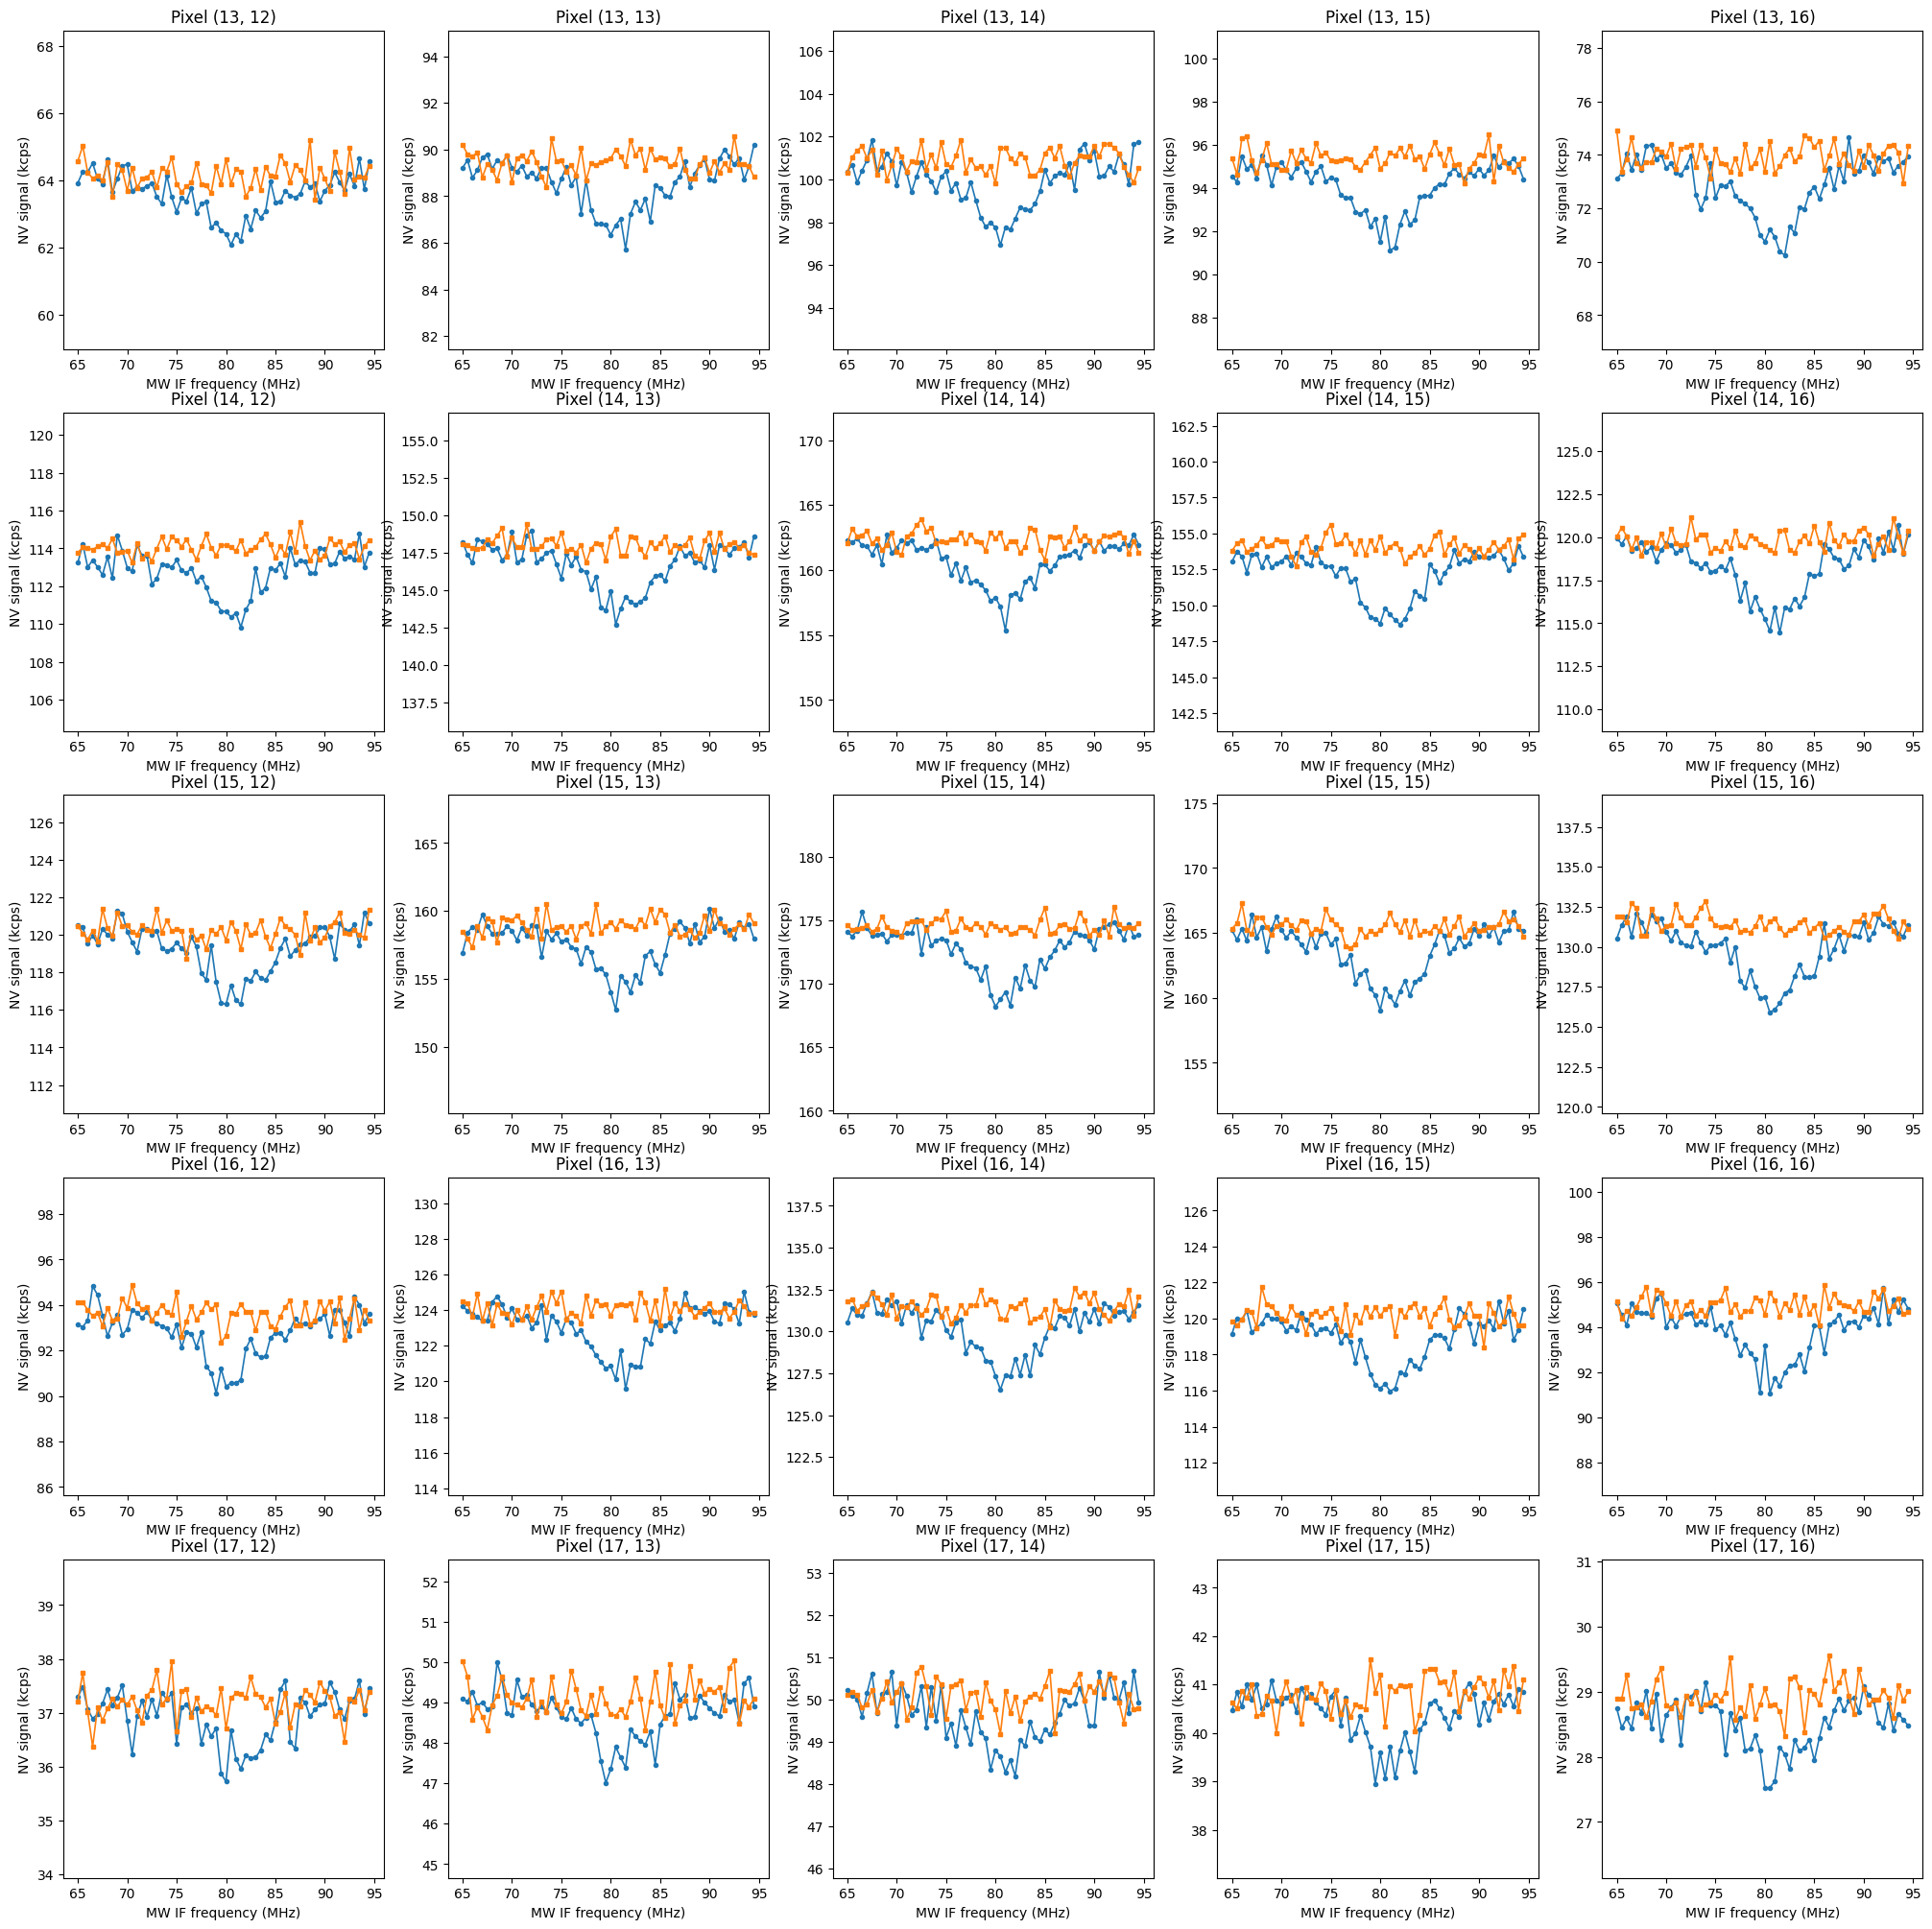

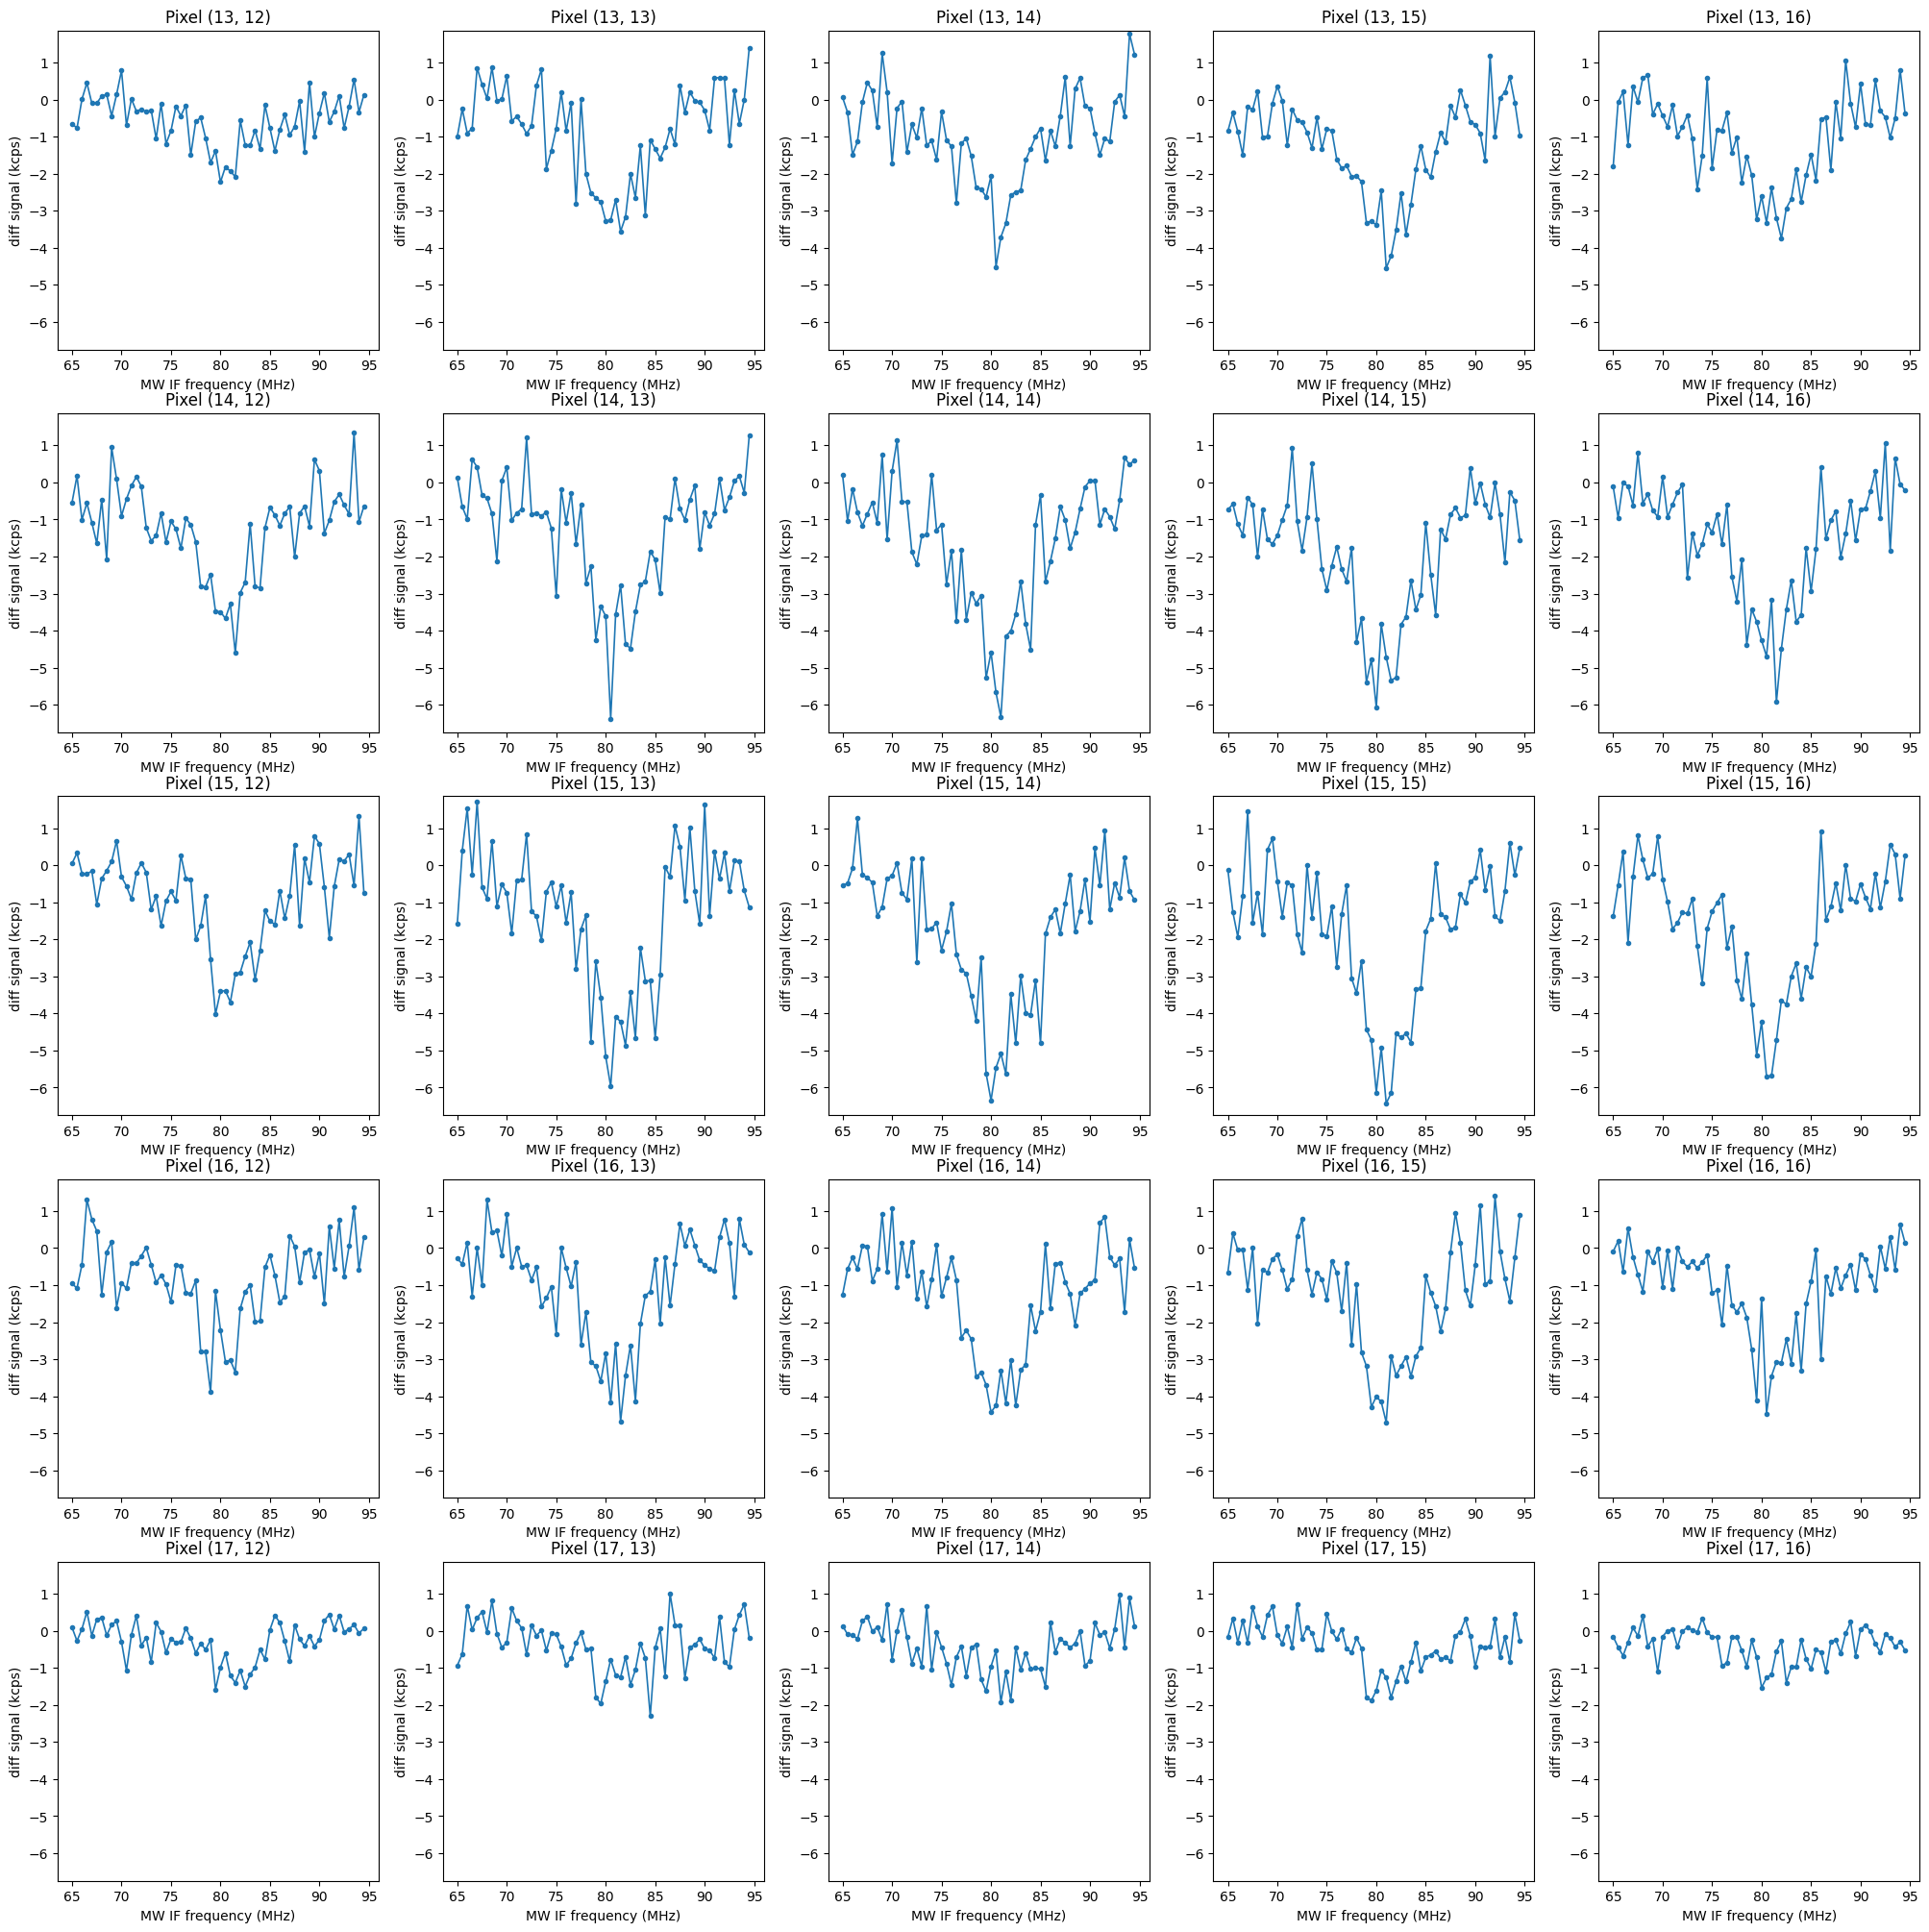

In [39]:
#make nXn grid of plots for pixels in ROI around emitter array center
plt.subplots(n, n, figsize=(5*n, 5*n))

for i in range(n):
    for j in range(n):
        sig = sig_avg_cps_bgsub[:, bright_rc[0]+i-int(n/2), bright_rc[1]+j-int(n/2)]
        ref = ref_avg_cps_bgsub[:, bright_rc[0]+i-int(n/2), bright_rc[1]+j-int(n/2)]

        plt.subplot(n, n, i*n + j + 1)
        plt.plot(f_mhz, sig*1e-3, 'o-', ms=3, lw=1.2, label='Signal')
        plt.plot(f_mhz, ref*1e-3, 's-', ms=3, lw=1.2, label='Reference')
        plt.ylim(min(sig.min(), ref.min()) * 0.95 *1e-3, max(sig.max(), ref.max()) * 1.05 *1e-3)
        plt.title(f'Pixel ({bright_rc[0]+i-int(n/2)}, {bright_rc[1]+j-int(n/2)})')
        plt.xlabel('MW IF frequency (MHz)')
        plt.ylabel('NV signal (kcps)')

plt.subplots(n, n, figsize=(5*n, 5*n))

# Global y-limits across all ROI (sig-ref) traces for consistent second-subplot scaling
global_min = np.inf
global_max = -np.inf
for i in range(n):
    for j in range(n):
        sig = sig_avg_cps_bgsub[:, bright_rc[0]+i-int(n/2), bright_rc[1]+j-int(n/2)]
        ref = ref_avg_cps_bgsub[:, bright_rc[0]+i-int(n/2), bright_rc[1]+j-int(n/2)]
        trace = sig - ref
        global_min = min(global_min, trace.min())
        global_max = max(global_max, trace.max())

for i in range(n):
    for j in range(n):
        sig = sig_avg_cps_bgsub[:, bright_rc[0]+i-int(n/2), bright_rc[1]+j-int(n/2)]
        ref = ref_avg_cps_bgsub[:, bright_rc[0]+i-int(n/2), bright_rc[1]+j-int(n/2)]

        plt.subplot(n, n, i*n + j + 1)
        plt.plot(f_mhz, 1e-3*(sig - ref), 'o-', ms=3, lw=1.2, label='Signal')
        if global_min > 0 and global_max > 0:
            plt.ylim(global_min * 0.95 * 1e-3, global_max * 1.05 * 1e-3)
        elif global_min < 0 and global_max < 0:
            plt.ylim(global_min * 1.05 * 1e-3, global_max * 0.95 * 1e-3)
        else:
            plt.ylim(global_min * 1.05 * 1e-3, global_max * 1.05 * 1e-3)
        plt.title(f'Pixel ({bright_rc[0]+i-int(n/2)}, {bright_rc[1]+j-int(n/2)})')
        plt.xlabel('MW IF frequency (MHz)')
        plt.ylabel('diff signal (kcps)')

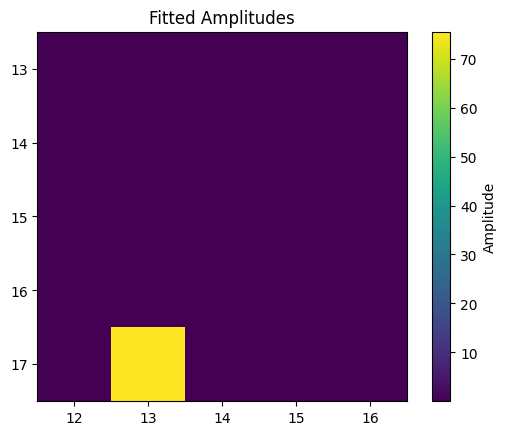

In [40]:
#fit Lorentzian to each pixel's contrast curve to extract amplitude, resonance frequency, and linewidth
from scipy.optimize import curve_fit
def lorentzian(f, f0, gamma, A, C):
    return A * (gamma**2 / ((f - f0)**2 + gamma**2)) + C
f0s = np.zeros((n, n))
gammas = np.zeros((n, n))
amps = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        sig = sig_avg_cps_bgsub[:, bright_rc[0]+i-int(n/2), bright_rc[1]+j-int(n/2)]
        ref = ref_avg_cps_bgsub[:, bright_rc[0]+i-int(n/2), bright_rc[1]+j-int(n/2)]
        contrast = np.where(ref != 0, (ref - sig) / ref, 0.0)

        try:
            popt, _ = curve_fit(lorentzian, f_mhz, contrast, p0=[f_mhz[np.argmin(contrast)], 10, contrast.min(), contrast.max()])
            f0s[i, j], gammas[i, j], amps[i, j] = popt[0], popt[1], popt[2]
        except RuntimeError:
            f0s[i, j], gammas[i, j], amps[i, j] = np.nan, np.nan, np.nan

    
# Plot fitted contrast amplitude, resonance frequency, and linewidth for each pixel in the ROI
plt.figure()
plt.imshow(amps, cmap='viridis', extent=[bright_rc[1]-int(n/2)-0.5, bright_rc[1]+int(n/2)+0.5, bright_rc[0]+int(n/2)+0.5, bright_rc[0]-int(n/2)-0.5])
plt.colorbar(label='Amplitude')
plt.title('Fitted Amplitudes')
plt.show()


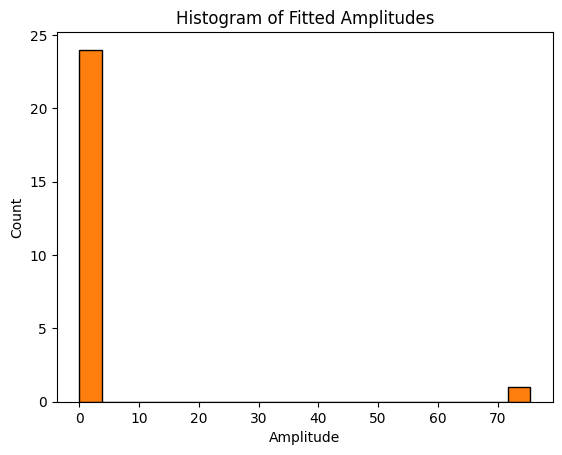

In [41]:
#plot histogram of amplitudes
plt.figure()
plt.hist(amps.flatten(), bins=20, color='C1', edgecolor='k')
plt.xlabel('Amplitude')
plt.ylabel('Count')
plt.title('Histogram of Fitted Amplitudes')
plt.show()